In [2]:
import pandas as pd 

df = pd.read_csv('BitCoin.csv')

In [3]:
df.columns

Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [4]:
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7483364 entries, 0 to 7483363
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 342.6 MB


In [6]:
df.isnull().sum()

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

In [7]:
import matplotlib.pyplot as plt

df = pd.read_csv("BitCoin.csv")

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)
df = df.sort_index()





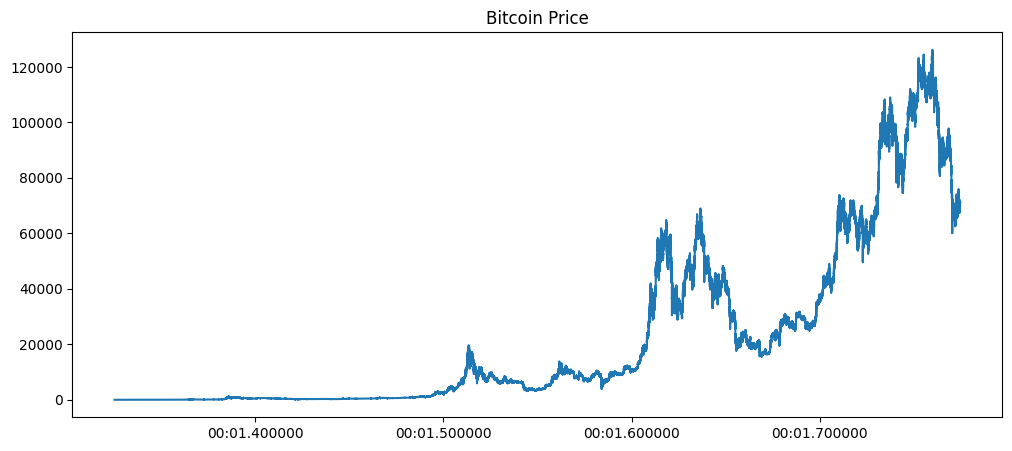

In [8]:
# Close price
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Bitcoin Price")
plt.show()

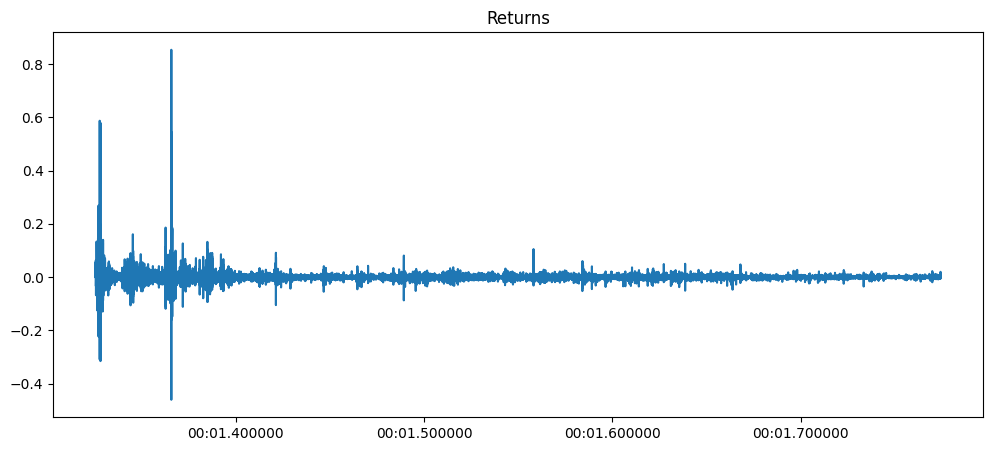

In [9]:
# Returns (volatility)
df['Returns'] = df['Close'].pct_change()
plt.figure(figsize=(12,5))
plt.plot(df['Returns'])
plt.title("Returns")
plt.show()

Linear Regression

In [10]:
df['lag1'] = df['Close'].shift(1)
df['lag2'] = df['Close'].shift(2)

df = df.dropna()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['lag1', 'lag2']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

pred_lr = model.predict(X_test)

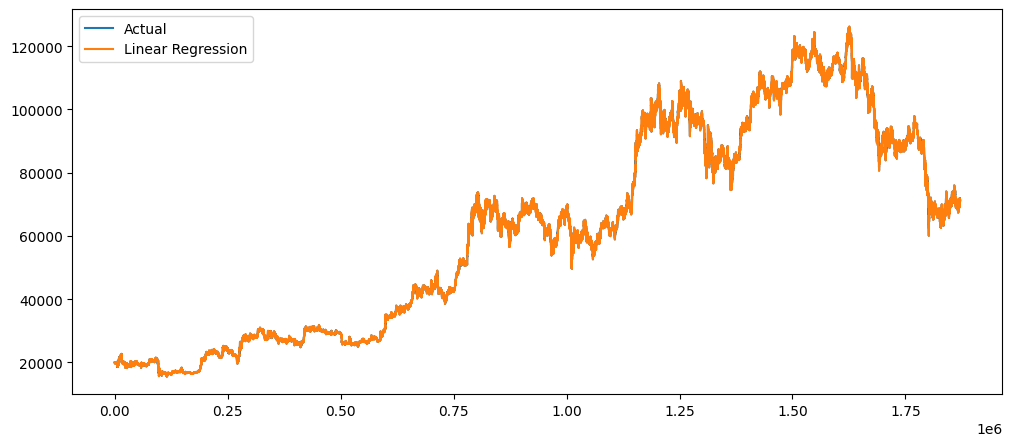

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(pred_lr, label='Linear Regression')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA


data = df['Close'].resample('H').mean()


data = data.replace([np.inf, -np.inf], np.nan).dropna()

print("Total data:", len(data))


split = int(len(data) * 0.8)

train = data[:split]
test = data[split:]

print("Train:", len(train), "Test:", len(test))


model = ARIMA(train, order=(1,1,1),
              enforce_stationarity=False,
              enforce_invertibility=False)

model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse_lr = mean_squared_error(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Metrics:")
print(f"MSE: {mse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")



Linear Regression Metrics:
MSE: 2034.33
MAE: 24.80
R² Score: 1.0000
